<a href="https://colab.research.google.com/github/ddezouza/Data201_DanielaMelo/blob/main/DanielaMelo_Week3Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Part I -- Visualization

###A. Scatterplots and Aesthetics

In [53]:
#Packages setup
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error

In [33]:
#Data Import
df = pd.read_csv("https://raw.githubusercontent.com/Reben80/Data201/refs/heads/main/Dataset/housing.csv")
df.head()

,listing_id,price,size,bedrooms,neighborhood,type
0,100001,145143.0,1280.741760,1.0,Suburb,Townhouse
1,100002,152251.0,1406.283113,2.0,Uptown,SingleFamily
2,100003,148251.0,4146.825713,6.0,Suburb,MultiFamily
3,100004,177711.0,3946.599818,6.0,Suburb,SingleFamily
4,100005,155269.0,1243.751760,1.0,Downtown,MultiFamily


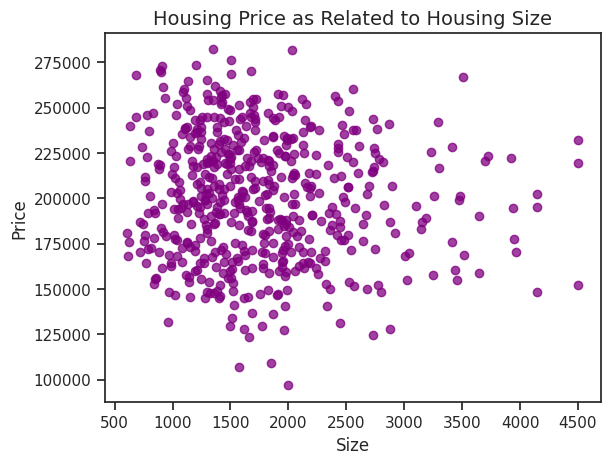

In [34]:
#Scatterplot of size vs price
plt.scatter(df['size'], df['price'], color='purple', alpha=0.75)
plt.xlabel('Size', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.title("Housing Price as Related to Housing Size", fontsize=14)
plt.show()

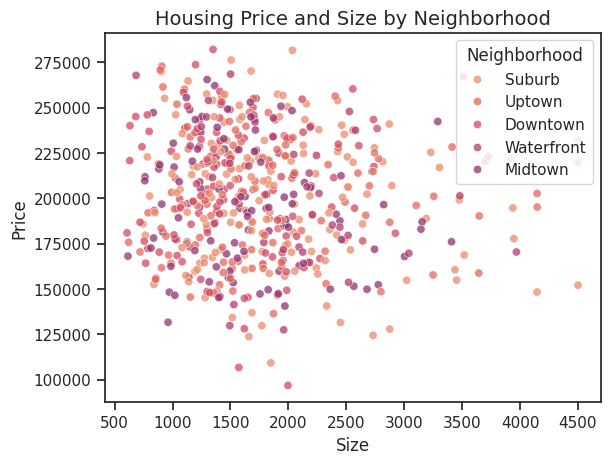

In [35]:
#Housing Price and Size by Neighborhood (seaborn)
sns.set_palette('flare')
sns.scatterplot(data=df, x='size', y='price', hue='neighborhood', alpha=0.75)
plt.xlabel('Size', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.title("Housing Price and Size by Neighborhood", fontsize=14)
plt.legend(title="Neighborhood")
plt.show()

- What does seaborn automatically handle that matplotlib does not?

Seaborn handles information from the dataframe more easily, does not require explicit callouts - it would label the axes using the column names for example, but since it draws from matplotlib you can use the plt.ylabel or plt.xlabel commands to fine tune the labeling (I capitalized and changed fontsize, for example). Seaborn is better for statistical plots because it has a lot of built in functionality that would require more work to draw out of matplotlib. It can also automatically translate data into visual properties - if we tried to use the df['neighborhood'] value to the color argument of plt.scatter, we'd get an error, but using 'neighgorhood' for the hue argument of sns.scatterplot automatically interprets the categorical values of 'neighborhood' into a visual element of the plot.

- Why is transparency useful here?

We have a lot of overlapping values. With transparency, we can more clearly depic this overlap while still highlighting the values are not necessarily the same, just close to each other. The differences in color paired with the transparency make the data points more visibly distinct from one another.

### B. Small Multiples (Faceting)

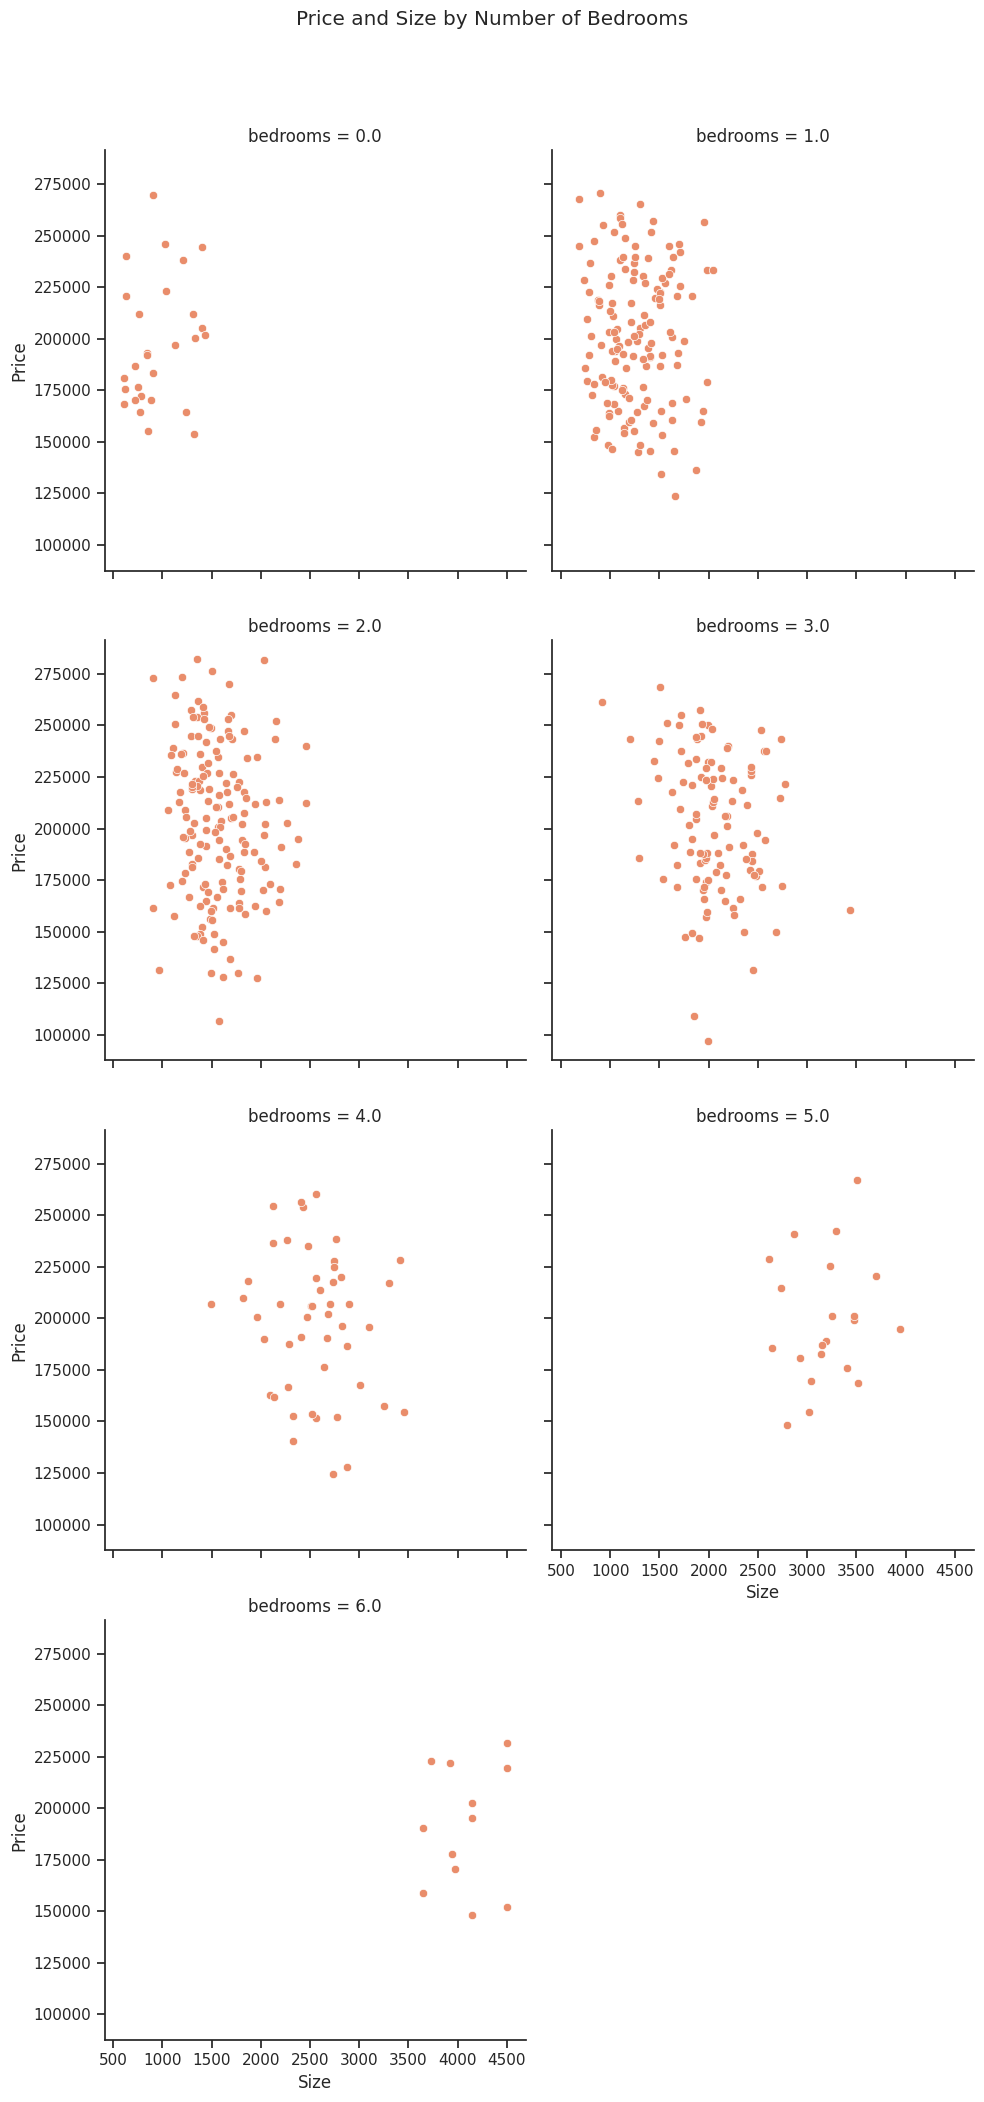

In [36]:
#Using code from slides
g = sns.relplot(data=df, x='size',y='price',col='bedrooms', kind='scatter',col_wrap=2)
g.set_axis_labels("Size", "Price")
g.fig.suptitle('Price and Size by Number of Bedrooms', y=1.05)
plt.show()

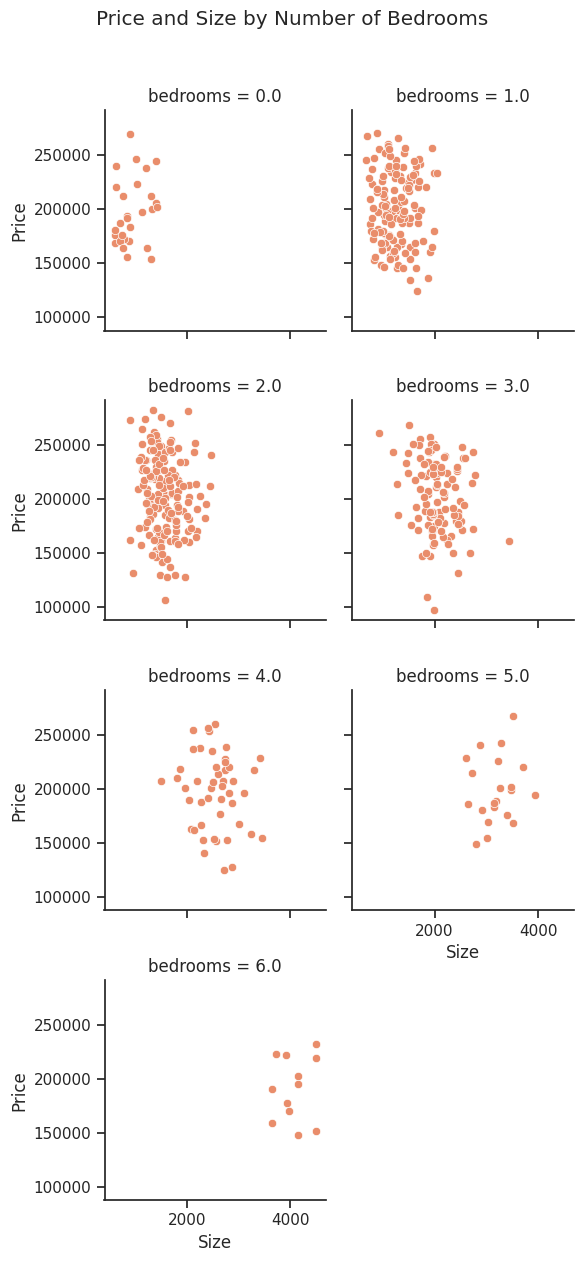

In [37]:
#Using alternate code
g = sns.FacetGrid(df, col='bedrooms', col_wrap=2)
g.map_dataframe(sns.scatterplot, x='size', y='price')
g.set_axis_labels("Size", "Price")
g.fig.suptitle('Price and Size by Number of Bedrooms', y=1.05)
plt.show()

- Does the relationship between size and price look similar accross bedroom counts?

The relationship seems to be more significant for houses with larger numbers of bedrooms. For housing with 1-3 bedrooms the relationship seems a lot less distinct. For housing with 5-6 bedrooms higher prices seem to be more closely related to larger sizes.

###C. Distribution and Categorical Plots

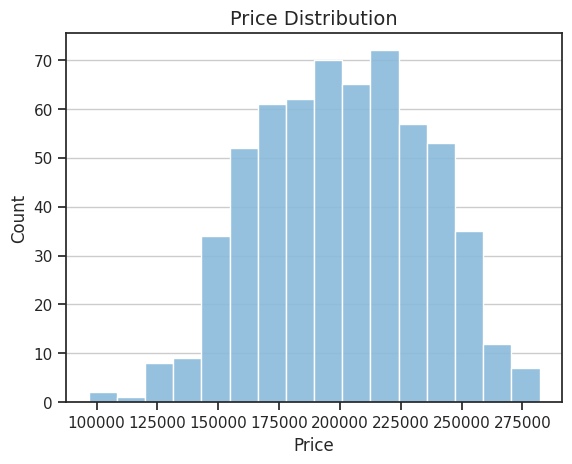

In [38]:
#Create a Histogram of Price
sns.set_theme(style='ticks')
sns.set_palette('Blues_d')
sns.histplot(data=df,x='price',kde=False, alpha=.90)
plt.xlabel('Price', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title("Price Distribution", fontsize=14)
plt.grid(True, axis='y',zorder=0)
plt.show()

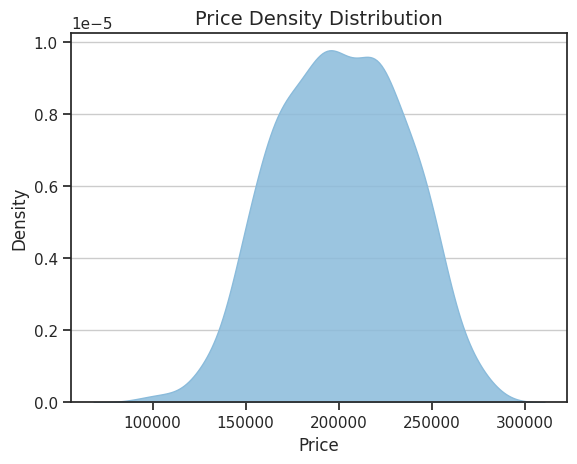

In [39]:
#Density Plot of Price
sns.kdeplot(data=df,x='price', fill=True,alpha=0.85)
plt.xlabel('Price', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title("Price Density Distribution", fontsize=14)
plt.grid(True, axis='y')
plt.show()

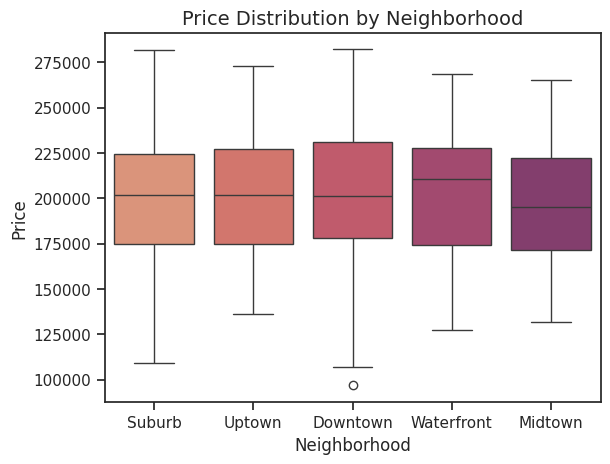

In [40]:
#Boxplot Neighborhood
sns.set_palette('flare')
sns.boxplot(data=df,x='neighborhood',y='price', hue='neighborhood')
plt.xlabel('Neighborhood', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.title("Price Distribution by Neighborhood", fontsize=14)
plt.grid(False)
plt.show()

- Do neighborhoods differ systematically in price?

Not really.

- What visual evidence supports your claim?

The middle 50% of houses accross all neighborhoods are at pretty similar prices. Median pricing for Suburb, Uptown, and Downtown housing looks to be very similar, though Waterfront houses have a higher median price. The different neighborhoods do have differences in pricing range but it doesn't look like they are systematically different in price.

##Part II -- Linear Regression for Inference

###A. Multiple Regression

In [59]:
#Fit equivalent model using statsmodels
model1 = smf.ols('price ~ size + bedrooms + C(neighborhood)', data=df).fit()
model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     1.460
Date:                Sun, 08 Mar 2026   Prob (F-statistic):              0.190
Time:                        22:13:51   Log-Likelihood:                -6212.8
No. Observations:                 524   AIC:                         1.244e+04
Df Residuals:                     517   BIC:                         1.247e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
=================================================================================================
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                      2.112e+05   4925.106     42.872      0.000    2.01e+05    2.21e+05
C(neighborhood)[T.Midtown]    -4236.1877   4809.529     -0.881      0.379   -1.37e+04    5212.435
C(neighborhood)[T.Suburb]      -562.7029   4369.989     -0.129      0.898   -9147.823    8022.417
C(neighborhood)[T.Uptown]      1311.1025   4727.959      0.277      0.782   -7977.272    1.06e+04
C(neighborhood)[T.Waterfront]  3001.3355   5984.299      0.502      0.616   -8755.198    1.48e+04
size                            -10.9345      4.210     -2.597      0.010     -19.205      -2.664
bedrooms                       4372.2643   2262.445      1.933      0.054     -72.453    8816.981
==============================================================================
Omnibus:                       12.814   Durbin-Watson:                   0.699
Prob(Omnibus):                  0.002   Jarque-Bera (JB):                7.598
Skew:                          -0.114   Prob(JB):                       0.0224
Kurtosis:                       2.456   Cond. No.                     1.05e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.05e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

1. Interpret the coefficient on *size*, explicitly stating what is being held constant.

The coefficient on size is -10.93 according to the model summary. This means that with neighborhood and bedrooms (meaning number of bedrooms) being held constant, a one unit increase in size is associated with a 10.93 decrease in price.

2. Is size statistically significant? How do you know?

Based on a p-value of 0.010 for size, we can claim that size is statistically significant.

3. What does R squared tell us in this context?

R squared for the model is 0.017. This shows the model is probably not a good fit to explain the cariation in price, because the model as is only explains about 1.7% of the variation for that variable. This could mean that neighborhood, size, and number of bedrooms are not strong explanatory variables for price, and that price is more impacted by variables that are not included in the model.

##Part III -- Prediction Workflow

In [54]:
#Split data into training and test sets
df1=df.dropna() #df has NaNs, dropping so I don't get an error
X = df1[["size","bedrooms"]]
y = df1['price']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

#fit linear regression using scikit learn
model2 = LinearRegression()
model2.fit(X_train,y_train)
y_pred=model2.predict(X_test)

#Compute RMSE
rmse=root_mean_squared_error(y_test,y_pred)
#Compute R squared
rsquared=r2_score(y_test,y_pred)

print(rmse)
print(rsquared)

33286.03902865655
-0.000655474883803242


- Why does scikit-learn not report p-values?

Scikit-learn is focused on prediction, not statistical significance. It is intended for prediction more than hypothesis testing.

- Which workflow would you use for explanation?

The statsmodel workflow is more explanatory.

- Which workflow would you use for prediction?

scikit-learn is prediction focused.

- Why are these different goals?

They are employed in different ways. If your intent is to deploy the model and you want accuracy in the predictive power of the model measuring effects or uncertainty of your current data won't be as valuable. Scikit is intended for prediction and deployment and is more concerned with accuracy of prediction than explaining the data.


## Part IV -- Integrated Thinking

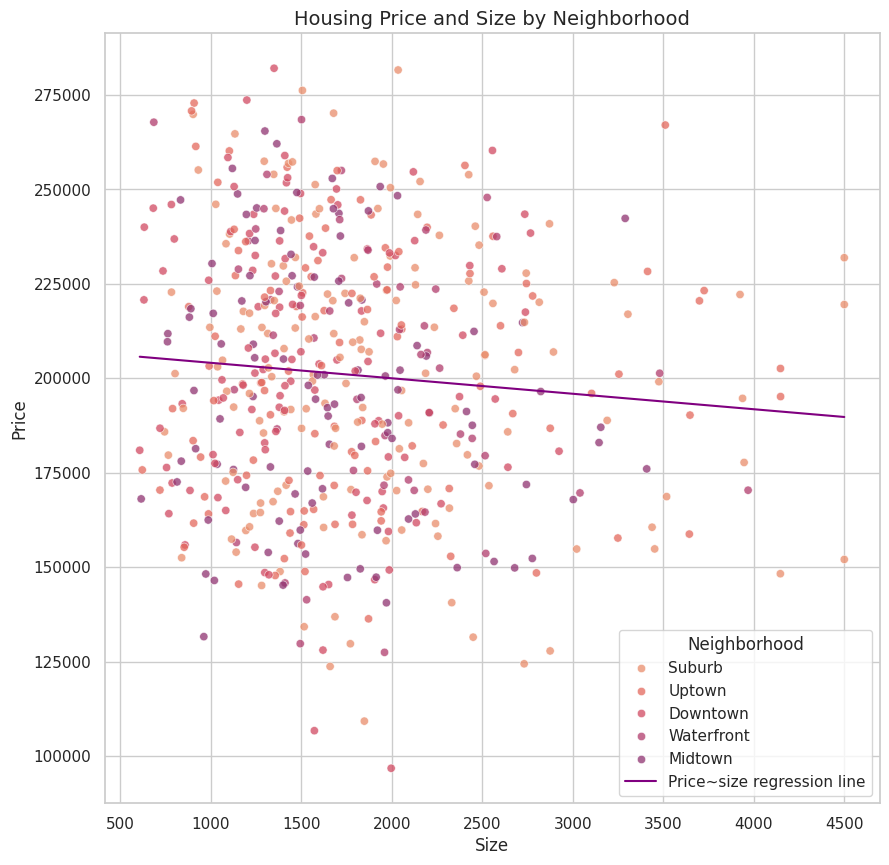

In [76]:
#Single figure that shows size vs. price, colors by neighborhood, includes a regression line, and has professional formating.

df2=df[['price', 'size','neighborhood']].dropna()

#Model for linear regression
X = df2[['size']].values
y = df2['price'].values

line = LinearRegression().fit(X,y)

x_line=np.linspace(df2['size'].min(),df2['size'].max(), 200)
y_line = line.predict(x_line.reshape(-1,1))

sns.set_palette('flare')
plt.figure(figsize=(10,10))
sns.scatterplot(data=df, x='size', y='price', hue='neighborhood', alpha=0.75)
plt.plot(x_line, y_line, label="Price~size regression line", color='purple')
plt.xlabel('Size', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.title("Housing Price and Size by Neighborhood", fontsize=14)
plt.legend(title="Neighborhood")
plt.show()


- Does the regression model match what you visually observed?

 The data is visually very spread out, so it is difficult to discern the relationship between size and price without the regression line. The models tested and the last regression are not a very good fit for the data, so it makes sense that there isn't a very close visual connection that can be discerned immediately. Once the regression line is plotted, the model makes a lot more sense.

- Did the visualization help you anticipate the model results?

When using just the scatterplot, no. The scatter does not clearly outline a relationship, so it is hard to try and predict model results from just the data. Once we plot the actual line, we have a better idea of the results, including a negative coefficient for size.